<a href="https://colab.research.google.com/github/NooNE268/Brain-Tumor/blob/main/Brain_tumor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [49]:
# Import Libraries
import streamlit as st
import tensorflow as tf
import cv2
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from PIL import Image

In [4]:
import tensorflow as tf

#Import Libraries
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import Conv2D

from tensorflow.keras.layers import MaxPooling2D

from tensorflow.keras.layers import Flatten

from tensorflow.keras.layers import Dense

from tensorflow.keras.layers import Dropout

import matplotlib.pyplot as plt

import numpy as np

In [5]:
#Data Preprocessing
# Image Augmentation
train_datagen = ImageDataGenerator(

    rescale=1./255,

    rotation_range=20,

    zoom_range=0.2,

    horizontal_flip=True,

    validation_split=0.2

)


In [6]:
#Mount the Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
#Define Paths
train_path = "/content/drive/MyDrive/Brain_Tumor/Training"
test_path = "/content/drive/MyDrive/Brain_Tumor/Testing"

In [8]:
#Create ImageDataGenerator
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

In [9]:
#Training Generator
train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode="categorical",
    subset="training"
)

Found 4480 images belonging to 4 classes.


In [10]:
import os

drive_brain_tumor_path = '/content/drive/MyDrive/Brain_Tumor'

if os.path.exists(drive_brain_tumor_path):
    print(f"Contents of '{drive_brain_tumor_path}':")
    for item in os.listdir(drive_brain_tumor_path):
        print(item)
else:
    print(f"The directory '{drive_brain_tumor_path}' does not exist in your Google Drive. Please ensure the 'Brain_Tumor' folder is directly in 'My Drive'.")

Contents of '/content/drive/MyDrive/Brain_Tumor':
Testing
Training


In [11]:
import os

my_drive_path = '/content/drive/MyDrive'

if os.path.exists(my_drive_path):
    print(f"Contents of '{my_drive_path}':")
    for item in os.listdir(my_drive_path):
        print(item)
else:
    print(f"The directory '{my_drive_path}' does not exist. This indicates an issue with the Google Drive mount.")

Contents of '/content/drive/MyDrive':
Common Videos
Picnic videos
Farewell videos
Abcd
Old whatsapp
Old camera
My scl memories
Fb 1
Screen shots
Birthdays
Whatsapp
Untitled presentation.gslides
GDToT
Asus 1
Whatsapp mots
Poem .gdoc
Untitled document.docx
physics (assignment-1).pdf
Physics (assignment-2).pdf
619676.pdf
Untitled spreadsheet (2).gsheet
Untitled spreadsheet (1).gsheet
transcribing_1_otter.ai.gdoc
transcribing_2__sg_X8_otter.ai.gdoc
current-transcriber-test_rtr_X6_otter.ai.gdoc
current-transcriber-test_otter (1).ai.gdoc
current-transcriber-test_otter.ai.gdoc
Screenshot_20200919-085039~2.png
Untitled document (9).gdoc
Untitled document (8).gdoc
WOEK.gdoc
PROGRAM AZ (1).gsheet
PROGRAM AZ
01phy..pdf
phy02.pdf
काश मैं भी एक तारा होता.docx
Untitled document (7).gdoc
Untitled document (6).gdoc
Untitled spreadsheet.gsheet
Untitled folder
Audio
Resume (4).gdoc
Resume (3).gdoc
Untitled document (5).gdoc
Resume (2).gdoc
Untitled document (4).gdoc
Project Chemistry..gdoc
Untitled docu

### Expected Folder Structure for `flow_from_directory`

For `flow_from_directory` to work correctly, your data should be structured like this:

```
Brain_Tumor/
├── Training/
│   ├── class1/          (e.g., 'glioma', 'meningioma')
│   │   ├── image1.jpg
│   │   ├── image2.png
│   │   └── ...
│   ├── class2/
│   │   ├── imageA.jpg
│   │   └── ...
│   └── ...
└── Testing/
    ├── class1/
    │   ├── test_image1.jpg
    │   └── ...
    ├── class2/
    │   ├── test_imageA.jpg
    │   └── ...
    └── ...
```

If your `Training` and `Testing` folders are directly inside `Brain_Tumor`, but they don't contain these class-specific subfolders with images, then `flow_from_directory` will report 'Found 0 images belonging to 0 classes', which is what you're currently seeing.

Please verify that your folders have this structure. I can provide code to list the contents of your `Training` and `Testing` subfolders if you'd like.

In [12]:
import os

# Verify the contents of the Training directory
print(f"\nContents of '{train_path}':")
if os.path.exists(train_path):
    items = os.listdir(train_path)
    if items:
        for item in items:
            print(item)
    else:
        print("The 'Training' directory is empty.")
else:
    print("The 'Training' directory does not exist.")

# Verify the contents of the Testing directory
print(f"\nContents of '{test_path}':")
if os.path.exists(test_path):
    items = os.listdir(test_path)
    if items:
        for item in items:
            print(item)
    else:
        print("The 'Testing' directory is empty.")
else:
    print("The 'Testing' directory does not exist.")



Contents of '/content/drive/MyDrive/Brain_Tumor/Training':
pituitary
meningioma
notumor
glioma

Contents of '/content/drive/MyDrive/Brain_Tumor/Testing':
pituitary
notumor
meningioma
glioma


In [13]:
import os

# Function to list contents of a directory with a limit
def list_dir_contents(path, limit=5):
    if os.path.exists(path):
        items = os.listdir(path)
        if items:
            print(f"Contents of '{path}' (first {limit} items):")
            for i, item in enumerate(items):
                if i < limit:
                    print(f"- {item}")
                else:
                    print(f"- ... ({len(items) - limit} more items)")
                    break
        else:
            print(f"The directory '{path}' is empty.")
    else:
        print(f"The directory '{path}' does not exist.")

# Check Training directory
print("\n--- Verifying Training Directory ---")
list_dir_contents(train_path)

# If Training directory exists and has contents, check one of its subfolders (if any)
if os.path.exists(train_path) and os.listdir(train_path):
    first_training_subfolder = os.path.join(train_path, os.listdir(train_path)[0])
    if os.path.isdir(first_training_subfolder):
        print(f"\n--- Verifying contents of a sample class folder in Training ({os.path.basename(first_training_subfolder)}) ---")
        list_dir_contents(first_training_subfolder)
    else:
        print(f"\n'{os.path.basename(first_training_subfolder)}' in Training is not a folder. Expected class subfolders.")

# Check Testing directory
print("\n--- Verifying Testing Directory ---")
list_dir_contents(test_path)

# If Testing directory exists and has contents, check one of its subfolders (if any)
if os.path.exists(test_path) and os.listdir(test_path):
    first_testing_subfolder = os.path.join(test_path, os.listdir(test_path)[0])
    if os.path.isdir(first_testing_subfolder):
        print(f"\n--- Verifying contents of a sample class folder in Testing ({os.path.basename(first_testing_subfolder)}) ---")
        list_dir_contents(first_testing_subfolder)
    else:
        print(f"\n'{os.path.basename(first_testing_subfolder)}' in Testing is not a folder. Expected class subfolders.")



--- Verifying Training Directory ---
Contents of '/content/drive/MyDrive/Brain_Tumor/Training' (first 5 items):
- pituitary
- meningioma
- notumor
- glioma

--- Verifying contents of a sample class folder in Training (pituitary) ---
Contents of '/content/drive/MyDrive/Brain_Tumor/Training/pituitary' (first 5 items):
- Tr-pi_1367.jpg
- Tr-pi_1336.jpg
- Tr-pi_158.jpg
- Tr-pi_1370.jpg
- Tr-pi_1377.jpg
- ... (1395 more items)

--- Verifying Testing Directory ---
Contents of '/content/drive/MyDrive/Brain_Tumor/Testing' (first 5 items):
- pituitary
- notumor
- meningioma
- glioma

--- Verifying contents of a sample class folder in Testing (pituitary) ---
Contents of '/content/drive/MyDrive/Brain_Tumor/Testing/pituitary' (first 5 items):
- Te-pi_117.jpg
- Te-pi_130.jpg
- Te-pi_155.jpg
- Te-pi_157.jpg
- Te-pi_137.jpg
- ... (395 more items)


In [14]:
import os

# Function to list contents of a directory with a limit (re-using the one defined before)
def list_dir_contents(path, limit=5):
    if os.path.exists(path):
        items = os.listdir(path)
        if items:
            print(f"Contents of '{path}' (first {limit} items):")
            for i, item in enumerate(items):
                if i < limit:
                    print(f"- {item}")
                else:
                    print(f"- ... ({len(items) - limit} more items)")
                    break
        else:
            print(f"The directory '{path}' is empty.")
    else:
        print(f"The directory '{path}' does not exist.")

print("\n--- Verifying contents of each class subfolder in Training ---")
if os.path.exists(train_path):
    class_subfolders = [os.path.join(train_path, f) for f in os.listdir(train_path) if os.path.isdir(os.path.join(train_path, f))]
    if class_subfolders:
        for class_folder in class_subfolders:
            print(f"\nChecking: {class_folder}")
            list_dir_contents(class_folder)
    else:
        print("No class subfolders found in the Training directory.")
else:
    print("The Training directory does not exist.")



--- Verifying contents of each class subfolder in Training ---

Checking: /content/drive/MyDrive/Brain_Tumor/Training/pituitary
Contents of '/content/drive/MyDrive/Brain_Tumor/Training/pituitary' (first 5 items):
- Tr-pi_1367.jpg
- Tr-pi_1336.jpg
- Tr-pi_158.jpg
- Tr-pi_1370.jpg
- Tr-pi_1377.jpg
- ... (1395 more items)

Checking: /content/drive/MyDrive/Brain_Tumor/Training/meningioma
Contents of '/content/drive/MyDrive/Brain_Tumor/Training/meningioma' (first 5 items):
- Tr-me_1229.jpg
- Tr-me_1215.jpg
- Tr-me_1223.jpg
- Tr-me_1283.jpg
- Tr-me_1232.jpg
- ... (1395 more items)

Checking: /content/drive/MyDrive/Brain_Tumor/Training/notumor
Contents of '/content/drive/MyDrive/Brain_Tumor/Training/notumor' (first 5 items):
- Tr-no_1293.jpg
- Tr-no_1351.jpg
- Tr-no_1326.jpg
- Tr-no_1349.jpg
- Tr-no_133.jpg
- ... (1395 more items)

Checking: /content/drive/MyDrive/Brain_Tumor/Training/glioma
Contents of '/content/drive/MyDrive/Brain_Tumor/Training/glioma' (first 5 items):
- Tr-gl_157.jpg
- T

In [15]:
import os

# Function to list contents of a directory with a limit (re-using the one defined before)
def list_dir_contents(path, limit=5):
    if os.path.exists(path):
        items = os.listdir(path)
        if items:
            print(f"Contents of '{path}' (first {limit} items):")
            for i, item in enumerate(items):
                if i < limit:
                    print(f"- {item}")
                else:
                    print(f"- ... ({len(items) - limit} more items)")
                    break
        else:
            print(f"The directory '{path}' is empty.")
    else:
        print(f"The directory '{path}' does not exist.")

print("\n--- Verifying contents of each class subfolder in Testing ---")
if os.path.exists(test_path):
    class_subfolders = [os.path.join(test_path, f) for f in os.listdir(test_path) if os.path.isdir(os.path.join(test_path, f))]
    if class_subfolders:
        for class_folder in class_subfolders:
            print(f"\nChecking: {class_folder}")
            list_dir_contents(class_folder)
    else:
        print("No class subfolders found in the Testing directory.")
else:
    print("The Testing directory does not exist.")


--- Verifying contents of each class subfolder in Testing ---

Checking: /content/drive/MyDrive/Brain_Tumor/Testing/pituitary
Contents of '/content/drive/MyDrive/Brain_Tumor/Testing/pituitary' (first 5 items):
- Te-pi_117.jpg
- Te-pi_130.jpg
- Te-pi_155.jpg
- Te-pi_157.jpg
- Te-pi_137.jpg
- ... (395 more items)

Checking: /content/drive/MyDrive/Brain_Tumor/Testing/notumor
Contents of '/content/drive/MyDrive/Brain_Tumor/Testing/notumor' (first 5 items):
- Te-no_133.jpg
- Te-no_111.jpg
- Te-no_119.jpg
- Te-no_117.jpg
- Te-no_103.jpg
- ... (395 more items)

Checking: /content/drive/MyDrive/Brain_Tumor/Testing/meningioma
Contents of '/content/drive/MyDrive/Brain_Tumor/Testing/meningioma' (first 5 items):
- Te-aug-me_11.jpg
- Te-aug-me_10.jpg
- Te-aug-me_3.jpg
- Te-aug-me_2.jpg
- Te-aug-me_21.jpg
- ... (395 more items)

Checking: /content/drive/MyDrive/Brain_Tumor/Testing/glioma
Contents of '/content/drive/MyDrive/Brain_Tumor/Testing/glioma' (first 5 items):
- Te-gl_103.jpg
- Te-gl_101.jpg

If the previous cell outputs show that your class folders now contain images, please re-run the `train_generator` and `test_generator` cells (cells `LgbkEcSIb0Qj` and `fsu7fUG4b3FY`) to load the data.

In [16]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

In [17]:
train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode="categorical",
    subset="training"
)

Found 4480 images belonging to 4 classes.


In [18]:
test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode="categorical",
    shuffle=False
)

Found 1600 images belonging to 4 classes.


In [19]:
import os

print(os.listdir("/content/drive/MyDrive/Brain_Tumor"))
print(os.listdir(train_path))

['Testing', 'Training']
['pituitary', 'meningioma', 'notumor', 'glioma']


In [20]:
import os

print(os.listdir("/content/drive/MyDrive/Brain_Tumor"))
print(os.listdir(train_path))

['Testing', 'Training']
['pituitary', 'meningioma', 'notumor', 'glioma']


In [21]:
train_generator = train_datagen.flow_from_directory(

    train_path,

    target_size=(224,224),

    batch_size=32,

    class_mode="categorical",

    subset="training"

)

Found 4480 images belonging to 4 classes.


In [22]:
validation_generator = train_datagen.flow_from_directory(

    test_path,

    target_size=(224,224),

    batch_size=32,

    class_mode="categorical",

    subset="validation"

)

Found 320 images belonging to 4 classes.


In [23]:
print(train_generator.class_indices)

{'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}


In [29]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

#CNN model
# Build CNN
model = Sequential()

model.add(

Conv2D(

32,

(3,3),

activation="relu",

input_shape=(224,224,3)

)

)

model.add(MaxPooling2D(pool_size=(2,2)))

model.add(

Conv2D(

64,

(3,3),

activation="relu"

)

)

model.add(MaxPooling2D(pool_size=(2,2)))

model.add(

Conv2D(

128,

(3,3),

activation="relu"

)

)

model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Flatten())

model.add(Dense(128,activation="relu"))

model.add(Dropout(0.5))

model.add(Dense(4,activation="softmax"))

In [25]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,476 (42.61 MB)

 Trainable params: 11,169,476 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [26]:
# Compile
model.compile(

optimizer="adam",

loss="categorical_crossentropy",

metrics=["accuracy"]

)

In [27]:
# Train
history = model.fit(

train_generator,

epochs=10,

validation_data=validation_generator

)

Epoch 1/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 939s 7s/step - accuracy: 0.5806 - loss: 0.9662 - val_accuracy: 0.6062 - val_loss: 1.0090
Epoch 2/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 616s 4s/step - accuracy: 0.7283 - loss: 0.6799 - val_accuracy: 0.6750 - val_loss: 0.9261
Epoch 3/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 624s 4s/step - accuracy: 0.7632 - loss: 0.6011 - val_accuracy: 0.6969 - val_loss: 0.8026
Epoch 4/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 619s 4s/step - accuracy: 0.7884 - loss: 0.5467 - val_accuracy: 0.6875 - val_loss: 1.0556
Epoch 5/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 613s 4s/step - accuracy: 0.7982 - loss: 0.5066 - val_accuracy: 0.7031 - val_loss: 0.9351
Epoch 6/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 610s 4s/step - accuracy: 0.8234 - loss: 0.4661 - val_accuracy: 0.7188 - val_loss: 0.8944
Epoch 7/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 616s 4s/step - accuracy: 0.8324 - loss: 0.4388 - val_accuracy: 0.7188 - val_loss: 0.8908
Epoch 8/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 607s 4s/step - accuracy: 0.8366 - loss: 0.4114 - val_accu

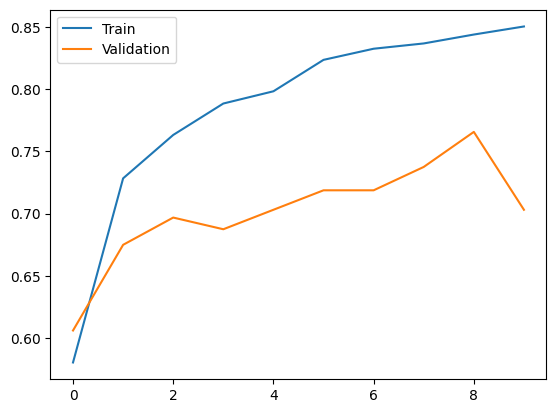

In [28]:
import matplotlib.pyplot as plt

#Model Performance
# Plot Accuracy
if 'history' in locals() and history is not None:
    plt.plot(history.history["accuracy"])
    plt.plot(history.history["val_accuracy"])
    plt.legend(["Train","Validation"])
    plt.show()
else:
    print("Error: 'history' object not found. Please ensure the model training cell (cell vHxMiRJXfp2e) was executed successfully.")

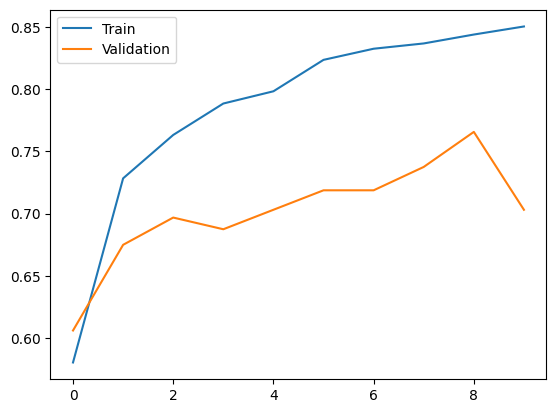

In [30]:
import matplotlib.pyplot as plt

# Plot Accuracy
if 'history' in locals() and history is not None:
    plt.plot(history.history["accuracy"])
    plt.plot(history.history["val_accuracy"])
    plt.legend(["Train","Validation"])
    plt.show()
else:
    print("Error: 'history' object not found. Please ensure the model training cell (cell vHxMiRJXfp2e) was executed successfully.")

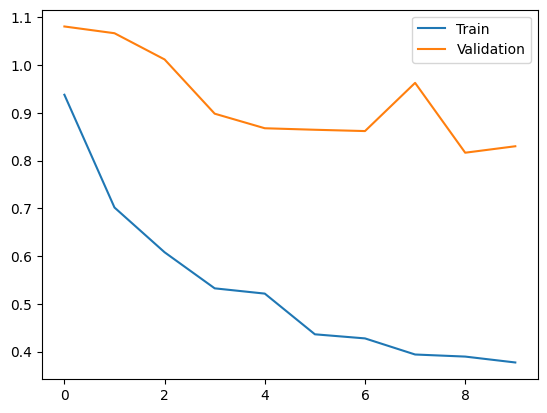

In [ ]:
plt.plot(history.history["loss"])

plt.plot(history.history["val_loss"])

plt.legend(["Train","Validation"])

plt.show()

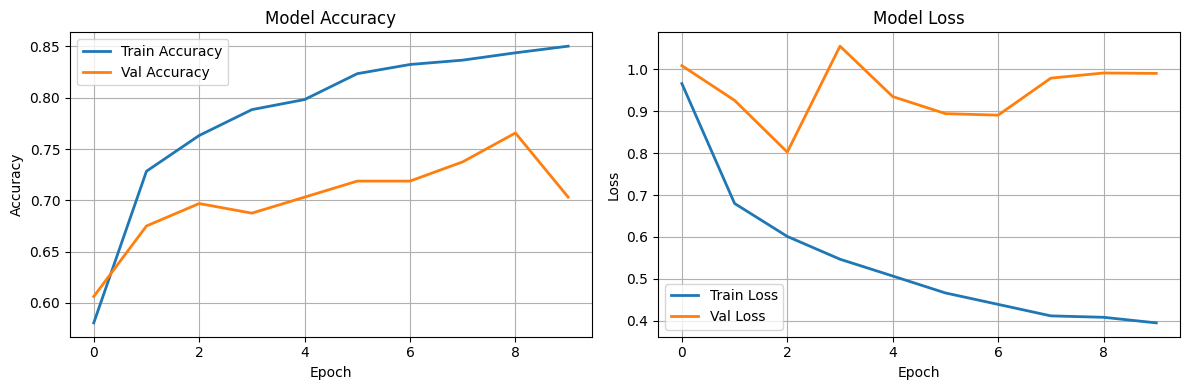

In [33]:
import matplotlib.pyplot as plt

# Check if history exists in memory
if 'history' in globals() or 'history' in locals():
    # Setup a 1x2 subplot figure
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # 1. Accuracy Plot
    if 'accuracy' in history.history:
        axes[0].plot(history.history['accuracy'], label='Train Accuracy', linewidth=2)
        axes[0].plot(history.history['val_accuracy'], label='Val Accuracy', linewidth=2)
        axes[0].set_title('Model Accuracy')
        axes[0].set_xlabel('Epoch')
        axes[0].set_ylabel('Accuracy')
        axes[0].legend()
        axes[0].grid(True)

    # 2. Loss Plot
    if 'loss' in history.history:
        axes[1].plot(history.history['loss'], label='Train Loss', linewidth=2)
        axes[1].plot(history.history['val_loss'], label='Val Loss', linewidth=2)
        axes[1].set_title('Model Loss')
        axes[1].set_xlabel('Epoch')
        axes[1].set_ylabel('Loss')
        axes[1].legend()
        axes[1].grid(True)

    plt.tight_layout()
    plt.show()
else:
    print("⚠️ Error: 'history' object not found in memory.")
    print("Please go back and run the cell with `history = model.fit(...)` first.")

In [40]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

loss,accuracy=model.evaluate(validation_generator)

print(accuracy)

10/10 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step - accuracy: 0.2562 - loss: 1.3905
0.2562499940395355


In [46]:
model.save("/content/drive/MyDrive/brain_tumor_model.keras")

In [47]:
# Load Model
from tensorflow.keras.models import load_model

model=load_model("/content/drive/MyDrive/brain_tumor_model.keras")

In [48]:
from tensorflow.keras.preprocessing import image

img=image.load_img(

"/content/drive/MyDrive/Brain_Tumor/Training/pituitary/Tr-pi_1367.jpg",

target_size=(224,224)

)

img=image.img_to_array(img)

img=img/255

img=np.expand_dims(img,axis=0)

In [42]:
prediction=model.predict(img)

classes=["Glioma",

"Meningioma",

"No Tumor",

"Pituitary"]

print(classes[np.argmax(prediction)])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step
Meningioma


In [43]:
import streamlit as st

uploaded_file = st.file_uploader(

"Upload MRI",

type=["jpg","png","jpeg"]

)

2026-07-27 10:04:55.589 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-27 10:04:55.590 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-27 10:04:55.604 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-27 10:04:56.115 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-07-27 10:04:56.116 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-27 10:04:56.117 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


In [44]:
if st.button("Predict"):

    prediction=model.predict(img)

    st.success(

    classes[np.argmax(prediction)]

    )

2026-07-27 10:05:00.284 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-27 10:05:00.286 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-27 10:05:00.288 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-27 10:05:00.290 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-27 10:05:00.291 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


In [45]:
confidence=np.max(prediction)*100

st.write(

f"Confidence : {confidence:.2f}%"

)

2026-07-27 10:05:02.084 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-27 10:05:02.085 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-27 10:05:02.088 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
